# This jupyter notebook is prepared by “Anish Hayman”.

# 1. Load Data and perform basic EDA (4pts total)

### 1.1 import libraries: numpy, pandas, matplotlib.pyplot, seaborn, sklearn (1pt)

In [34]:
# TODO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Upload the dataset to your Google Drive, then using the following code, import the data to a pandas dataframe and show the count of rows and columns (0.5pt)

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
from google.colab import drive

file_name = '/content/drive/MyDrive/Colab Notebooks/hr_data_.csv' #you may need to change this line depending on the location of your file in Google Drive
with open(file_name, 'r') as file:
    # TODO
  df = pd.read_csv(file_name)
# TODO


rows = len(df.axes[0])
cols = len(df.axes[1])

print(df)
print("Num of rows: ", rows)
print("Num of columns: ", cols)

      Unnamed: 0  enrollee_id      city  city_development_index  gender  \
0              1        29725   city_40                   0.776    Male   
1              4          666  city_162                   0.767    Male   
2              7          402   city_46                   0.762    Male   
3              8        27107  city_103                   0.920    Male   
4             11        23853  city_103                   0.920    Male   
...          ...          ...       ...                     ...     ...   
8950       19147        21319   city_21                   0.624    Male   
8951       19149          251  city_103                   0.920    Male   
8952       19150        32313  city_160                   0.920  Female   
8953       19152        29754  city_103                   0.920  Female   
8954       19155        24576  city_103                   0.920    Male   

          relevent_experience enrolled_university education_level  \
0      No relevent experience 

### 1.3 Show the top 7 and bottom 7 rows (0.5pt)

In [37]:
# TODO
print(df.loc[0:7])
print(df.tail(7))

   Unnamed: 0  enrollee_id      city  city_development_index gender  \
0           1        29725   city_40                   0.776   Male   
1           4          666  city_162                   0.767   Male   
2           7          402   city_46                   0.762   Male   
3           8        27107  city_103                   0.920   Male   
4          11        23853  city_103                   0.920   Male   
5          12        25619   city_61                   0.913   Male   
6          15         6588  city_114                   0.926   Male   
7          20        31972  city_159                   0.843   Male   

       relevent_experience enrolled_university education_level  \
0   No relevent experience       no_enrollment        Graduate   
1  Has relevent experience       no_enrollment         Masters   
2  Has relevent experience       no_enrollment        Graduate   
3  Has relevent experience       no_enrollment        Graduate   
4  Has relevent experience    

### 1.4 Show if any column has null values (0.5pt)

In [38]:
# TODO
print(df.isnull().sum())

Unnamed: 0                0
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


### 1.5 Show/Plot the count of unique target labels and discuss its imbalances and possible issues in using it for classification. (1.5pt)

The target values are imbalanced. This means that the data is not reliable for classification as it does not give enough information for one possible outcome to infer and classify future data.


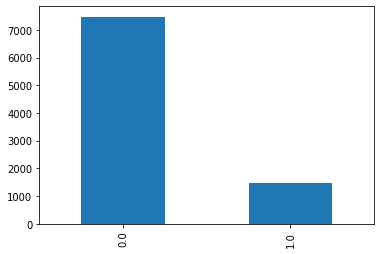

In [39]:
# TODO
pd.value_counts(df['target']).plot(kind = 'bar')
print("The target values are imbalanced. This means that the data is not reliable for classification as it does not give enough information for one possible outcome to infer and classify future data.")

# 2. Feature Selection and Pre-processing (25 pts total)

## 2.1 Preprocessing City (1+1+1+1 = 4pts total)

### 2.1.1 Plot no. of records per city so that the highest city counts are shown in descending order (1pt)

<AxesSubplot:>

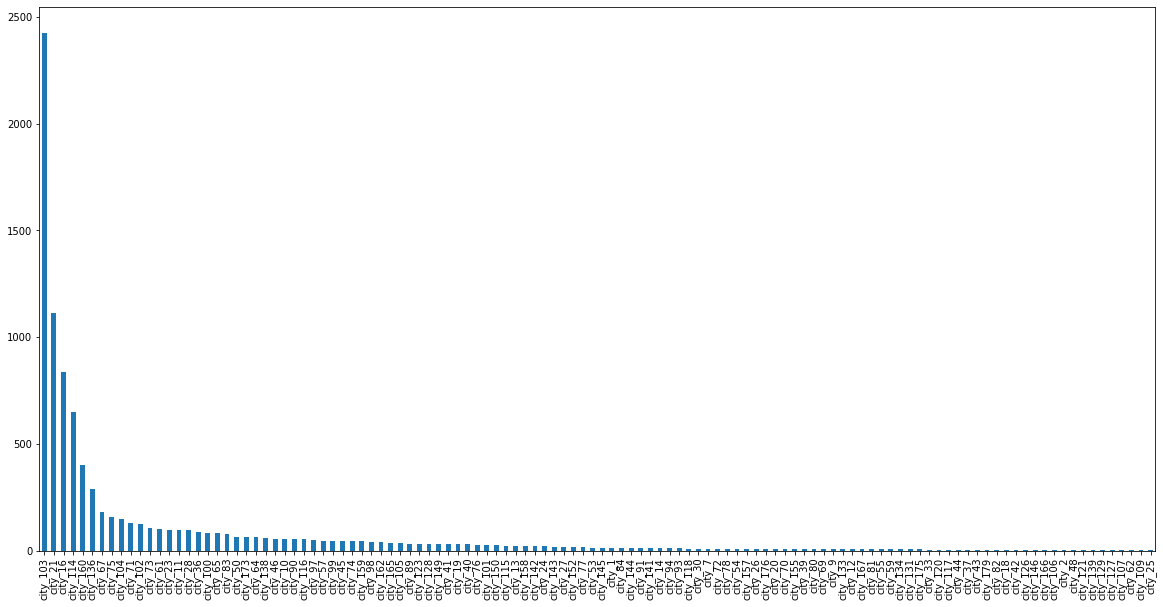

In [40]:
# TODO
plt.figure(figsize = (20, 10))
pd.value_counts(df['city']).sort_values(ascending = False).plot(kind = 'bar')


### 2.1.2 How many rows belong to the count-wise top 4 cities in total and how many for the remaining? (1pt)

In [41]:
from pandas.core.base import value_counts
# TODO
topCities = pd.value_counts(df['city']).sort_values(ascending = False).index[0:4].tolist()
numTopCities = len(df[df['city'].isin(topCities)].axes[0])
print("Top 4 cities rows = ",  numTopCities)

print("Remaining cities rows = ",  rows - numTopCities)

Top 4 cities rows =  5021
Remaining cities rows =  3934


### 2.1.3 Replace the city name with city_others if the city name is not among the top 4 (1pt)

In [42]:
# TODO
df['city'].mask(~df['city'].isin(topCities), 'city_others', inplace=True)


### 2.1.4 Show some sample data that the records have changed correctly. (1pt)

In [43]:
# TODO
df['city']

0       city_others
1       city_others
2       city_others
3          city_103
4          city_103
           ...     
8950        city_21
8951       city_103
8952    city_others
8953       city_103
8954       city_103
Name: city, Length: 8955, dtype: object

## 2.2. Preprocessing Education Level (1+2+2+1 = 6pts total)

### 2.2.1. Show the unique values of education level. (1pt)

In [44]:
# TODO
df['education_level'].unique()

array(['Graduate', 'Masters', 'Phd'], dtype=object)

### 2.2.2. Write a function named replace_labels() that can replace labels using given {old_label:new_label} dictionary (2pts)

Parameters: (1) dataframe, (2) a column name, (3) a dictionary with {old_label:new_label} mapping. 

Returns: a dataframe with specified column values replaced with the  


In [45]:
# TODO

def replace_labels(df, column_name, dictionary):
  df = df.replace({column_name : dictionary})

  return df


### 2.2.3. Using the replace_labels() function you just created, replace education_level column with ordinal values. The mapping can be like "Graduate":0, "Masters":1, "Phd":2 . (2pt)

In [46]:
# TODO

education_dict = {
    "Graduate" : 0,
    "Masters" : 1,
    "Phd" : 2
}

df = replace_labels(df, 'education_level', education_dict)



### 2.2.4 Show some sample data that the records have changed appropriately (1pt)

In [47]:
# TODO

df['education_level']

0       0
1       1
2       0
3       0
4       0
       ..
8950    0
8951    1
8952    0
8953    0
8954    0
Name: education_level, Length: 8955, dtype: int64

## 2.3. Preprocessing company_size (2+2+1 = 5pts total)

### 2.3.1 Show the unique values of the company_size column and their counts (2pt)

In [48]:
# TODO
print(pd.value_counts(df['company_size']))

50-99        1986
100-500      1814
10000+       1449
10/49         951
1000-4999     930
<10           840
500-999       592
5000-9999     393
Name: company_size, dtype: int64


### 2.3.2 Change the values of the company_size column from 0 to 7 where e0 is <10 and 7 is 10000+. The order of the numbers should be based on the values of the column-like an ordinary variable. (2pt)
(Hint: you can use the replace_labels() function you created before.)

In [49]:
# TODO
company_size_dict = {
    "<10" : 0,
    "10/49" : 1,
    "50-99" : 2,
    "100-500" : 3,
    "500-999" : 4,
    "1000-4999" : 5,
    "5000-9999" : 6,
    "10000+" : 7
}

df = replace_labels(df, 'company_size', company_size_dict)

### 2.3.3 Show the updated unique values to validate they changed appropriately (1pt)

In [50]:
# TODO

df['company_size']

0       2
1       2
2       0
3       2
4       6
       ..
8950    3
8951    2
8952    3
8953    1
8954    2
Name: company_size, Length: 8955, dtype: int64

## 2.4. Preprocessing last_new_job (1+2+1 = 4pts total)

### 2.4.1 Show unique values of the last_new_job column (1pt)

In [51]:
# TODO

df['last_new_job'].unique()

array(['>4', '4', '1', '3', '2', 'never'], dtype=object)

### 2.4.2 Convert the values of this column to never->0, 1->1,....>4 -->5 (2pt)
Hint: replace_labels()

In [52]:
# TODO
last_new_job_dict = {
    "never" : 0,
    "1" : 1,
    "2" : 2,
    "3" : 3,
    "4" : 4,
    ">4" : 5
}

df = replace_labels(df, 'last_new_job', last_new_job_dict)

### 2.4.3 Show the updated values (1pt)

In [53]:
# TODO

df['last_new_job']

0       5
1       4
2       5
3       1
4       1
       ..
8950    1
8951    1
8952    3
8953    1
8954    4
Name: last_new_job, Length: 8955, dtype: int64

## 2.5 Preprocessing other columns (2pt total)

### 2.5.1 Drop the enrollee_id, any unnamed columns, and any duplicate columns (if you created multiple columns one with original and one with updated, then remove the original one) (2pt)

In [54]:
# TODO

df.drop(columns = ['enrollee_id', "Unnamed: 0"], inplace=True)
df

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_others,0.776,Male,No relevent experience,no_enrollment,0,STEM,15.0,2,Pvt Ltd,5,47,0.0
1,city_others,0.767,Male,Has relevent experience,no_enrollment,1,STEM,21.0,2,Funded Startup,4,8,0.0
2,city_others,0.762,Male,Has relevent experience,no_enrollment,0,STEM,13.0,0,Pvt Ltd,5,18,1.0
3,city_103,0.920,Male,Has relevent experience,no_enrollment,0,STEM,7.0,2,Pvt Ltd,1,46,1.0
4,city_103,0.920,Male,Has relevent experience,no_enrollment,0,STEM,5.0,6,Pvt Ltd,1,108,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8950,city_21,0.624,Male,No relevent experience,Full time course,0,STEM,1.0,3,Pvt Ltd,1,52,1.0
8951,city_103,0.920,Male,Has relevent experience,no_enrollment,1,STEM,9.0,2,Pvt Ltd,1,36,1.0
8952,city_others,0.920,Female,Has relevent experience,no_enrollment,0,STEM,10.0,3,Public Sector,3,23,0.0
8953,city_103,0.920,Female,Has relevent experience,no_enrollment,0,Humanities,7.0,1,Funded Startup,1,25,0.0


In [55]:
# TODO

## 2.6 Feature Scaling (3+1 = 4ps total)

### 2.6.1 Use sklearn.preprocessing's MinMaxScaler to perform min max scaling to all the numeric columns (3pt)

In [56]:
# TODO
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_df = df.select_dtypes(include = ['number'])
df[num_df.columns] = scaler.fit_transform(num_df)



In [57]:
# TODO

### 2.6.2 Show some of the scaled records. (1pt)

In [58]:
# TODO
df

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,city_others,0.654691,Male,No relevent experience,no_enrollment,0.0,STEM,0.714286,0.285714,Pvt Ltd,1.0,0.137313,0.0
1,city_others,0.636727,Male,Has relevent experience,no_enrollment,0.5,STEM,1.000000,0.285714,Funded Startup,0.8,0.020896,0.0
2,city_others,0.626747,Male,Has relevent experience,no_enrollment,0.0,STEM,0.619048,0.000000,Pvt Ltd,1.0,0.050746,1.0
3,city_103,0.942116,Male,Has relevent experience,no_enrollment,0.0,STEM,0.333333,0.285714,Pvt Ltd,0.2,0.134328,1.0
4,city_103,0.942116,Male,Has relevent experience,no_enrollment,0.0,STEM,0.238095,0.857143,Pvt Ltd,0.2,0.319403,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8950,city_21,0.351297,Male,No relevent experience,Full time course,0.0,STEM,0.047619,0.428571,Pvt Ltd,0.2,0.152239,1.0
8951,city_103,0.942116,Male,Has relevent experience,no_enrollment,0.5,STEM,0.428571,0.285714,Pvt Ltd,0.2,0.104478,1.0
8952,city_others,0.942116,Female,Has relevent experience,no_enrollment,0.0,STEM,0.476190,0.428571,Public Sector,0.6,0.065672,0.0
8953,city_103,0.942116,Female,Has relevent experience,no_enrollment,0.0,Humanities,0.333333,0.142857,Funded Startup,0.2,0.071642,0.0


# 3. X/Y and Training/Test Split with stratified sampling (15pts in total)

### 3.1 Using a lot of features with categorical values is not memory-efficient. Use a LabelEncoder() to convert all the categorical columns to numeric labels. (This task is similar to previous assignment A1) (2pt)

In [59]:
# TODO
from sklearn import preprocessing
df2 = df
label_encoder = preprocessing.LabelEncoder()
catdf2 = df2.select_dtypes(include=['object','category'])
numdf2 = df2.select_dtypes(include = ['number'])

catdf2 = catdf2.apply(label_encoder.fit_transform)

df2 = pd.concat([catdf2, numdf2], axis = 1)
df2

,city,gender,relevent_experience,enrolled_university,major_discipline,company_type,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target
0,4,1,1,2,5,5,0.654691,0.0,0.714286,0.285714,1.0,0.137313,0.0
1,4,1,0,2,5,1,0.636727,0.5,1.000000,0.285714,0.8,0.020896,0.0
2,4,1,0,2,5,5,0.626747,0.0,0.619048,0.000000,1.0,0.050746,1.0
3,0,1,0,2,5,5,0.942116,0.0,0.333333,0.285714,0.2,0.134328,1.0
4,0,1,0,2,5,5,0.942116,0.0,0.238095,0.857143,0.2,0.319403,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8950,3,1,1,0,5,5,0.351297,0.0,0.047619,0.428571,0.2,0.152239,1.0
8951,0,1,0,2,5,5,0.942116,0.5,0.428571,0.285714,0.2,0.104478,1.0
8952,4,0,0,2,5,4,0.942116,0.0,0.476190,0.428571,0.6,0.065672,0.0
8953,0,0,0,2,2,1,0.942116,0.0,0.333333,0.142857,0.2,0.071642,0.0


### 3.2 Copy all the features into X and the target to Y (2pt)

In [82]:
# TODO

X = df2.loc[:, df2.columns!='target']
Y = df2['target']


### 3.3 Show the ratio of 1 and 0 in Y. (1pt)

In [61]:
# TODO
pd.value_counts(Y)

0.0    7472
1.0    1483
Name: target, dtype: int64

### 3.4 Use sklearn's train_test_split() to split the data set into 70% training and 30% test sets. Set random_state to 42. We want to have the same ratio of 0 and 1 in the test set, use the stratify parameter to Y to ensure this. Then show the ratio of 1 and 0 in both train and test target. (4pt)

In [62]:
# TODO
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42, stratify=Y)

print(pd.value_counts(y_train))
print("Train ratio: ", 5230 / 1038)
print(pd.value_counts(y_test))
print("Test ratio: ", 2242 / 445)

0.0    5230
1.0    1038
Name: target, dtype: int64
Train ratio:  5.038535645472062
0.0    2242
1.0     445
Name: target, dtype: int64
Test ratio:  5.038202247191011


### 3.5 Rebalancing (4+2 = 6pts)

3.5.1 Use imblearn's SMOTENC to balance the x_train


When our training set have class imbalance, we often perform over-sampling to generate synthetic data that can help in training. SMOTE is a library by imblearn for this purpose. The usage is fairly straightforward. See documentation [here](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) and a brief explanation with example [here](https://medium.com/analytics-vidhya/smote-nc-in-ml-categorization-models-fo-imbalanced-datasets-8adbdcf08c25)

In [63]:
# TODO
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

3.5.2 Did that change the ratio in label? Confirm by printing the ratio in resampled labels.

In [64]:
# TODO
print(pd.value_counts(y_res))

0.0    5230
1.0    5230
Name: target, dtype: int64


# 4. Decision Tree (20pts total)

### 4.1 Initialize a decision tree model using sklearns DecisionTreeClassifier. Use the unbalanced training set. Set a consistent value for random_state parameter so that your result is reproducible. (1pt)

In [65]:
# TODO
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)


### 4.2 Use grid search to find out the best combination of values for the parameters: criterion, max_depth, min_samples_split, max_features. Then print the best performing parameters. (4pt)

In [66]:
# TODO
from sklearn.model_selection import GridSearchCV
params = [{
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [2,4,6,8,10,12],
    'min_samples_split' : [5,10,20,50,100],
    'max_features' : ['sqrt', 'log2', None]
}]

gridS = GridSearchCV(estimator= decision_tree, param_grid=params, scoring='accuracy')
gridS.fit(X_train,y_train)
best_params = gridS.best_params_

### 4.3 Add the best performing parameter set to the already-initialized Decision Tree model. Then fit it on the train dataset. (2pt)

In [67]:
# TODO
decision_tree.set_params(**best_params)
decision_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2, min_samples_split=5, random_state=42)

### 4.4 Import the accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score from scikitlearn's metrics package. Evaluate your Decision Tree on the Test dataset and print all the metrics. (3pt)

In [68]:
# TODO
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

test_decision_tree = decision_tree.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test, decision_tree.predict(X_test) * 100))
print("Recall Score: ",(recall_score(y_test, decision_tree.predict(X_test)) / 1) * 100)
print("Confusion Matrix: \n",confusion_matrix(y_test, decision_tree.predict(X_test)))
print("f1 Score: ",(f1_score(y_test, decision_tree.predict(X_test) / 1) * 100 ))
print("roc_auc Score: ", (roc_auc_score(y_test, decision_tree.predict(X_test) / 1) * 100))


Accuracy Score:  0.7726088574618534
Recall Score:  51.91011235955057
Confusion Matrix: 
 [[2076  166]
 [ 214  231]]
f1 Score:  54.86935866983374
roc_auc Score:  72.253004440257


### 4.5 Plot the tree using scikitlearn's tree package. You may need to define a large figure size using matplotlib to have an intelligible figure. (2pt)

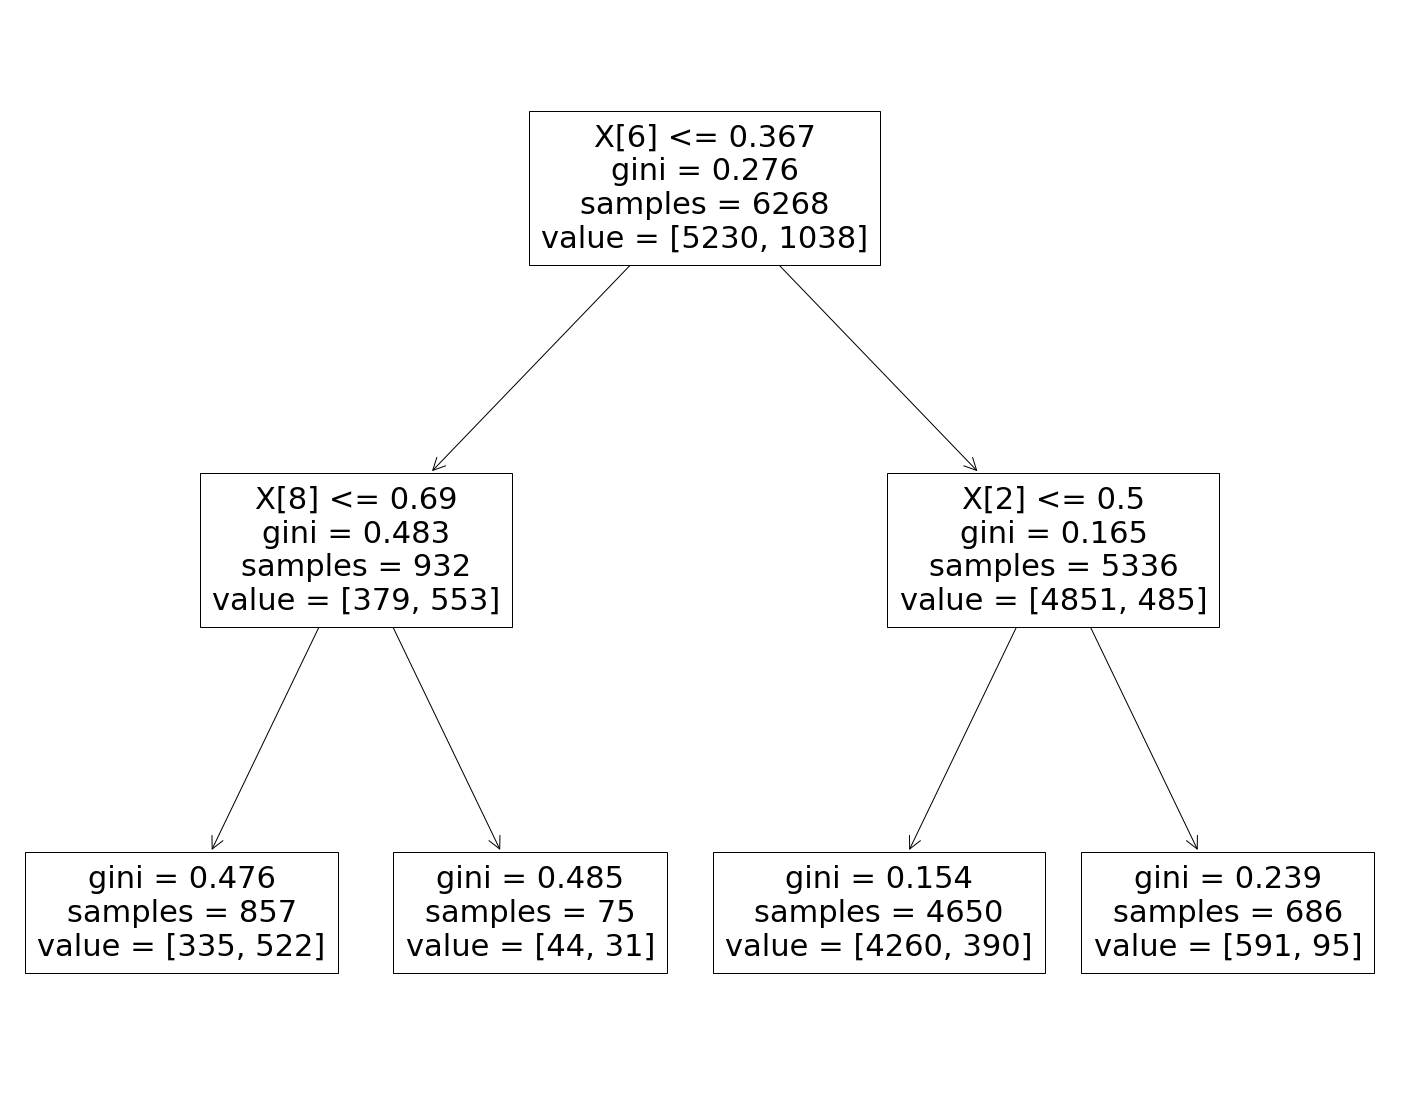

In [69]:
# TODO
from sklearn import tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(decision_tree=decision_tree)

### 4.6 Initialize a new Decision Tree model, then use the best set of parameters from Step 4.3 to train it on the balanced train set that you prepared in Step 3.5.1. (3pt)

In [70]:
# TODO

decision_tree2 = DecisionTreeClassifier(random_state=42)
decision_tree2.set_params(**best_params)
decision_tree2.fit(X_res,y_res)

DecisionTreeClassifier(max_depth=2, min_samples_split=5, random_state=42)

### 4.7 Print the evaluation scores (accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score) from the training on balanced dataset. (3pt)

In [71]:
# TODO

print("Accuracy Score: ",accuracy_score(y_res, decision_tree2.predict(X_res) * 100))
print("Recall Score: ",(recall_score(y_res, decision_tree2.predict(X_res)) / 1) * 100)
print("Confusion Matrix: \n",confusion_matrix(y_res, decision_tree2.predict(X_res)))
print("f1 Score: ",(f1_score(y_res, decision_tree2.predict(X_res) / 1) * 100 ))
print("roc_auc Score: ", (roc_auc_score(y_res, decision_tree2.predict(X_res) / 1) * 100))

Accuracy Score:  0.4627151051625239
Recall Score:  52.7151051625239
Confusion Matrix: 
 [[4840  390]
 [2473 2757]]
f1 Score:  65.82308702399426
roc_auc Score:  72.62906309751435


### 4.8 Discuss any difference between evaluation results from the unbalanced train set and balanced train set. (2pt)

'#TODO'

The confusion matrix between the balanced and the regular dataset is different. The balanced dataset has equal amounts of true positvies as true negatives. This results in an accuracy score of 0.5 compared to the higher accuracy of the unbalanced set.

# 5. Random Forest Classifier (12pts total)

### 5.1 Use grid search to find best combinations of the following Random Forest parameters: n_estimators, max_depth, min_samples_split and min_samples_leaf. Use your own choice of scoring, criterion, number of folds for cross-validation for the model initialization. Remember the grid search can take a while to finish. (4pt)

In [72]:
# TODO
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42)

forest_params = [{
    'n_estimators' : [5,10,15,20],
    'max_depth' : [2,4,6,8,10,12],
    'min_samples_split' : [5,10,20,50,100],
    'min_samples_leaf' : [5,10,20,50,100]
}]

gridS2 = GridSearchCV(estimator= forest, param_grid=forest_params, scoring='accuracy')
gridS2.fit(X_train,y_train)
best_params2 = gridS2.best_params_

### 5.2 Print the best combination of parameters and use it to train a Random Forest classifier model. (3pt)

In [73]:
# TODO

print(best_params2)
forest.set_params(**best_params2)

{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50, 'n_estimators': 20}


RandomForestClassifier(max_depth=10, min_samples_leaf=20, min_samples_split=50,
                       n_estimators=20, random_state=42)

### 5.3  Evaluate using the same metrics as before (accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score) (5pt)

In [74]:
# TODO

forest.fit(X_train,y_train)
print("Accuracy Score: ",accuracy_score(y_test, forest.predict(X_test) * 100))
print("Recall Score: ",(recall_score(y_test, forest.predict(X_test)) / 1) * 100)
print("Confusion Matrix: \n",confusion_matrix(y_test, forest.predict(X_test)))
print("f1 Score: ",(f1_score(y_test, forest.predict(X_test) / 1) * 100 ))
print("roc_auc Score: ", (roc_auc_score(y_test, forest.predict(X_test) / 1) * 100))


Accuracy Score:  0.7759583178265724
Recall Score:  49.21348314606742
Confusion Matrix: 
 [[2085  157]
 [ 226  219]]
f1 Score:  53.3495736906212
roc_auc Score:  71.10540348204351


# 6. Boosting Classifier (20 pts total)

## 6.1 AdaBoost Classifier (10 pts total)

### 6.1.1 Perform a grid search for best values for parameters={n_estimators, learning_rate} of an AdaBoostClassifier and the given training set. (4pt) 

In [75]:
# TODO
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(random_state=42)

boost_params = [{
    'n_estimators' : [5,10,15,20],
    'learning_rate' : [0.01, 0.02,0.05,0.07,0.1]
}]

gridS3 = GridSearchCV(estimator= boost, param_grid=boost_params, scoring='accuracy')
gridS3.fit(X_train,y_train)
best_params3 = gridS3.best_params_

### 6.1.2 Train an AdaboostClassifier using the best parameter set you found in step 6.1.1 (3pt) 

In [76]:
# TODO
print(best_params3)
boost.set_params(**best_params3)

{'learning_rate': 0.01, 'n_estimators': 5}


AdaBoostClassifier(learning_rate=0.01, n_estimators=5, random_state=42)

### 6.1.3 Evaluate using the same metrics as before (accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score) (3pt)

In [77]:
# TODO

boost.fit(X_train,y_train)
print("Accuracy Score: ",accuracy_score(y_test, boost.predict(X_test) * 100))
print("Recall Score: ",(recall_score(y_test, boost.predict(X_test)) / 1) * 100)
print("Confusion Matrix: \n",confusion_matrix(y_test, boost.predict(X_test)))
print("f1 Score: ",(f1_score(y_test, boost.predict(X_test) / 1) * 100 ))
print("roc_auc Score: ", (roc_auc_score(y_test, boost.predict(X_test) / 1) * 100))

Accuracy Score:  0.7673985857834016
Recall Score:  55.0561797752809
Confusion Matrix: 
 [[2062  180]
 [ 200  245]]
f1 Score:  56.32183908045977
roc_auc Score:  73.51381691707846


## 6.2 Gradient Boosting Classifier (10 pts total)

### 6.2.1 Perform a grid search for best values for parameters={n_estimators, max_depth, learning_rate} of a GradientBoostingClassifier and the given training set. (4pt)

In [78]:
# TODO
from sklearn.ensemble import GradientBoostingClassifier

grad_boost = AdaBoostClassifier(random_state=42)

grad_boost_params = [{
    'n_estimators' : [5,10,15,20],
    'max_depth' : [2,4,6,8,10,12],
    'learning_rate' : [0.01, 0.02,0.05,0.07,0.1]
}]

gridS4 = GridSearchCV(estimator= boost, param_grid=boost_params, scoring='accuracy')
gridS4.fit(X_train,y_train)
best_params4 = gridS4.best_params_

### 6.2.2 Train a GradientBoostingClassifier using the best parameter set you found in step 6.2.1 (3pt) 

In [79]:
# TODO
print(best_params4)
boost.set_params(**best_params4)

{'learning_rate': 0.01, 'n_estimators': 5}


AdaBoostClassifier(learning_rate=0.01, n_estimators=5, random_state=42)

### 6.2.3 Evaluate using the same metrics as before (accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score) (3pt)

In [80]:
# TODO

grad_boost.fit(X_train,y_train)
print("Accuracy Score: ",accuracy_score(y_test, grad_boost.predict(X_test) * 100))
print("Recall Score: ",(recall_score(y_test, grad_boost.predict(X_test)) / 1) * 100)
print("Confusion Matrix: \n",confusion_matrix(y_test, grad_boost.predict(X_test)))
print("f1 Score: ",(f1_score(y_test, grad_boost.predict(X_test) / 1) * 100 ))
print("roc_auc Score: ", (roc_auc_score(y_test, grad_boost.predict(X_test) / 1) * 100))

Accuracy Score:  0.7752139933010793
Recall Score:  48.31460674157304
Confusion Matrix: 
 [[2083  159]
 [ 230  215]]
f1 Score:  52.50305250305251
roc_auc Score:  70.6113622467901


# 7. Summary Discussion (4 pts)

Which model yields the highest precision?



> Answer : RandomForest has the highest precision with: 92.97%  
(AdaBoost: 91.97,   GradientBoosting: 92.908,   DecisionTree(balanced): 92.54,   DecisionTree: 92.59)



Which model yields the lowest recall? 



>   Answer: GradientBoosting  has the lowest recall with 48.31



Which model yields the higest True Positive (TP)? 


> The balanced dataset has the highest True Positive value. From the other models, the RandomFOrest has the highest True Positive.



Which model yields the best performance overall? 


> RandomForest has the highest accuracy of 0.7795 and the highest precision so it has the best performance overall.



